# PROACT in human PBMC scATAC-seq data

This tutorial demonstrates the PROACT workflow in human PBMC scATAC-seq data. Upstream quality control, dimensionality reduction, clustering, and cell-type annotation follow the Signac PBMC workflow. The analysis starts from a preprocessed and annotated scATAC-seq object and focuses on PROACT-specific steps.

> **Reproducibility note:** The code-cell outputs shown in this notebook are preserved from the original analysis run. Local file paths reflect the original analysis environment and should be updated before rerunning the notebook.

## Load the preprocessed scATAC-seq dataset

pbmc.atac.rds was got by following the Signac tutorial: [Analyzing PBMC scATAC-seq](https://stuartlab.org/signac/articles/pbmc_vignette)

In [1]:
library(Seurat)
#read RDS
pbmc <- readRDS("examples/hPBMC/pbmc.atac.rds")
pbmc

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Signac



An object of class Seurat 
184991 features across 9641 samples within 2 assays 
Active assay: RNA (19615 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: peaks
 2 dimensional reductions calculated: lsi, umap

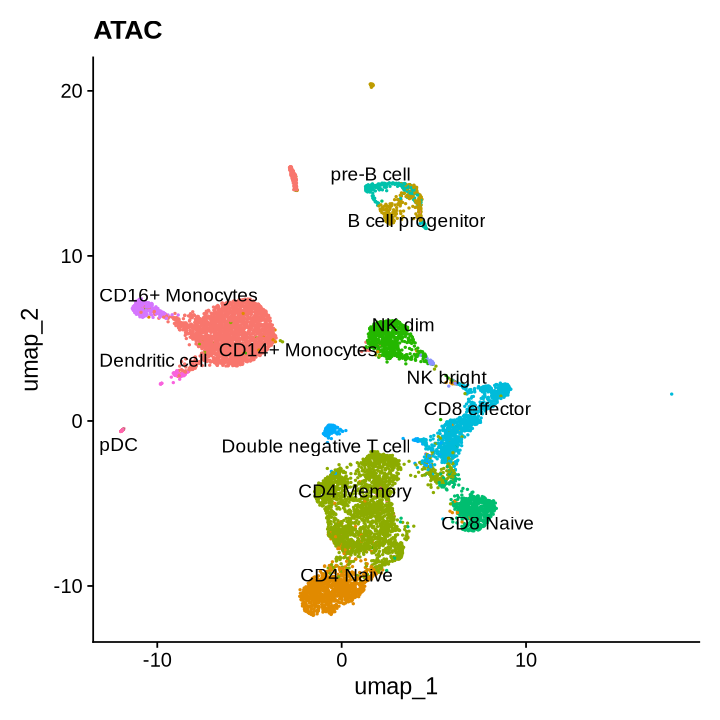

In [2]:
# UMAP
library(ggplot2)
options(repr.plot.width = 6, repr.plot.height = 6)
DimPlot(pbmc, 
        label = T,
        repel = TRUE) + NoLegend() + ggtitle('ATAC')

## Identify cell-type-specific accessible peaks

In [3]:
# 1. Identify cell-type-specific differential accessible peaks
DefaultAssay(pbmc) <- 'peaks'
da_peaks <- FindAllMarkers(
    object = pbmc,
    only.pos = TRUE,
    test.use = "wilcox",
    return.thresh = 0.01,
    min.pct = 0.1,
    logfc.threshold = 0.1
)

colnames(da_peaks)[7] <- "Peak"

# Filter peaks
da_peaks <- da_peaks[da_peaks$pct.1 > 0.25 & da_peaks$avg_log2FC > 0.25,]


# 2. Construct peak x cell-cluster matrix
cluster_mat <- data.frame(Peak = rownames(pbmc[["peaks"]]["counts"]),check.names = FALSE)
rownames(cluster_mat) <- cluster_mat$Peak
idents <- as.character(unique(Idents(pbmc)))

for (ident in idents) {
    features <- da_peaks$Peak[da_peaks$cluster == ident]
    features <- intersect(features, cluster_mat$Peak)
    cluster_mat[features, ident] <- 1

    message(ident, " has ", length(features), " features.")
}

#write.csv(cluster_mat,"cellcluster_DApeaks.csv",row.names = FALSE,quote = FALSE)

Calculating cluster CD14+ Monocytes

Calculating cluster CD4 Naive

Calculating cluster B cell progenitor

Calculating cluster CD4 Memory

Calculating cluster NK dim

Calculating cluster CD8 Naive

Calculating cluster pre-B cell

Calculating cluster CD8 effector

Calculating cluster Double negative T cell

Calculating cluster NK bright

Calculating cluster CD16+ Monocytes

Calculating cluster Dendritic cell

Calculating cluster pDC

CD14+ Monocytes has 6514 features.

CD4 Naive has 3074 features.

B cell progenitor has 4997 features.

CD4 Memory has 4743 features.

NK dim has 4657 features.

CD8 Naive has 3730 features.

pre-B cell has 4264 features.

CD8 effector has 4800 features.

Double negative T cell has 5032 features.

NK bright has 3462 features.

CD16+ Monocytes has 6670 features.

Dendritic cell has 9266 features.

pDC has 6932 features.



## Prepare motif information

Two motif-derived inputs are prepared for PROACT. First, motif positions are stored in the scATAC-seq object for downstream spatial grammar analysis. Second, motifs are rescanned within the central 200 bp of each peak to generate a binary peak-by-motif matrix for cooperative TF inference.

In [5]:
# ==============================================================================
# Motif preparation for PROACT
# ==============================================================================

library(Signac)
library(motifmatchr)
library(TFBSTools)
library(JASPAR2024)
library(BSgenome.Hsapiens.UCSC.hg38)
library(GenomicRanges)
library(GenomeInfoDb)

DefaultAssay(pbmc) <- "peaks"
genome <- BSgenome.Hsapiens.UCSC.hg38
p_cutoff <- 1e-4
region_length <- 200

# 1. Load JASPAR2024 human CORE motifs
pfm <- getMatrixSet(
    x = "~data/JASPAR2024.sqlite",
    opts = list(collection = "CORE", tax_group = "vertebrates",
                species = "Homo sapiens", all_versions = FALSE)
)

# 2. Add motif matrix and motif positions to the scATAC-seq object
peak_gr <- granges(pbmc)

motif_matrix <- CreateMotifMatrix(
    features = peak_gr, pwm = pfm, genome = genome,
    use.counts = FALSE, p.cutoff = p_cutoff
)

keep <- as.character(seqnames(peak_gr)) %in% seqlevels(genome)

motif_positions <- motifmatchr::matchMotifs(
    pwms = pfm, subject = peak_gr[keep], out = "positions",
    genome = genome, p.cutoff = p_cutoff
)

seqinfo(motif_positions) <- seqinfo(genome)[seqlevels(motif_positions)]

motif_obj <- CreateMotifObject(
    data = motif_matrix,
    positions = motif_positions,
    pwm = pfm
)

pbmc[["peaks"]]@motifs <- motif_obj

# Optional: save the object with motif positions for grammar analysis
saveRDS(pbmc, file = "examples/hPBMC/pbmc_preprocessed_with_motifs.rds")


# 3. Generate the central 200-bp peak x motif matrix
peak_gr <- granges(pbmc)
peak_gr$peakID <- rownames(pbmc[["peaks"]])

chrom_sizes <- seqlengths(genome)
keep_chr <- intersect(c(paste0("chr", 1:22), "chrX", "chrY"), names(chrom_sizes))
chrom_sizes <- chrom_sizes[keep_chr]

peak_seqinfo <- Seqinfo(seqnames = names(chrom_sizes), seqlengths = chrom_sizes)
seqlevels(peak_gr) <- seqlevels(peak_seqinfo)
seqinfo(peak_gr) <- peak_seqinfo

peak_gr <- trim(resize(peak_gr, width = region_length, fix = "center"))

motif_matrix_200 <- CreateMotifMatrix(
    features = peak_gr, pwm = pfm, genome = genome,
    use.counts = FALSE, p.cutoff = p_cutoff
)

peak_motif <- as.data.frame(motif_matrix_200)
peak_motif[] <- lapply(peak_motif, function(x) if (is.logical(x)) as.integer(x) else x)
peak_motif <- data.frame(peakID = peak_gr$peakID, peak_motif, check.names = FALSE)

# Remove chrY only after motif scanning
peak_chr <- sub("-.*$", "", peak_motif$peakID)
peak_motif <- peak_motif[peak_chr %in% c(paste0("chr", 1:22), "chrX"),,drop = FALSE]


# 4. Retain motifs included in the PROACT annotation
motif_anno_file <- system.file("extdata", "metadata.tsv", package = "PROACT")
motif_anno <- read.table(motif_anno_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

keep_motifs <- intersect(motif_anno$motif_id, colnames(peak_motif))
peak_motif <- peak_motif[, c("peakID", keep_motifs), drop = FALSE]

write.table(
    peak_motif,
    file = "examples/hPBMC/pbmc_peak_motif.central200bp.p1e-4.tsv",
    row.names = FALSE, col.names = TRUE, sep = "\t", quote = FALSE
)



Loading required package: BiocFileCache

Loading required package: dbplyr

Loading required package: GenomeInfoDb

Loading required package: BiocGenerics

Loading required package: generics

Warning message:
“package ‘generics’ was built under R version 4.7.0”

Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr1_KI270759v1_alt, chr1_KI270760v1_alt, chr1_KI270761v1_alt, chr1_KI270762v1_alt, chr1_KI270763v1_alt, chr1_KI270764v1_alt, chr1_KI270765v1_alt, chr1_KI270766v1_alt, chr1_KI270892v1_alt, chr2_GL383521v1_alt, chr2_GL383522v1_alt, chr2_GL582966v2_alt, chr2_KI270767v1_alt, chr2_KI270768v1_alt, chr2_KI270769v1_alt, chr2_KI270770v1_alt, chr2_KI270771v1_alt, chr2_KI270772v1_alt, chr2_KI270773v1_alt, chr2_KI270774v1_alt, chr2_KI270775v1_alt, chr2_KI270776v1_alt, chr2_KI270893v1_alt, chr2_KI270894v1_alt, chr3_GL383526v1_alt, chr3_JH636055v2_alt, chr3_KI270777v1_alt, chr3_KI270778v1_alt, chr3_KI270779v1_alt, chr3_KI270780v1_alt, chr3_KI270781v1_alt, chr3_KI270782v1_alt, chr3_KI270783v1_alt, chr3_KI270784v1_alt, chr3_KI270895v1_alt, chr3_KI270924v1_alt, chr3_KI270934v1_alt, chr3_KI270935v1_alt

Warning message in CreateMotifObject(data = motif_matrix, positions = motif_positions, :
“Non-unique motif names supplied, making unique”


## Identify overrepresented motifs as target TFs

In [12]:
#table(Idents(pbmc))


       CD14+ Monocytes              CD4 Naive      B cell progenitor 
                  2541                   1119                    294 
            CD4 Memory                 NK dim              CD8 Naive 
                  2596                    693                    626 
            pre-B cell           CD8 effector Double negative T cell 
                   245                    972                    172 
             NK bright        CD16+ Monocytes         Dendritic cell 
                    44                    241                     67 
                   pDC 
                    31 

Motif enrichment was performed for cell-type-specific differential accessible peaks using FindMotifs. Significantly enriched motifs (FDR < 0.05) were ranked by adjusted P value and fold enrichment, and the top 100 motifs were mapped to TFs and used as target TFs for PROACT inference. You could also select TFs that you are interested in.  

In [6]:
# ==============================================================================
# Identification of target TFs
# ==============================================================================

# Calculate sequence features required by FindMotifs
pbmc <- RegionStats(object = pbmc, assay = "peaks", genome = BSgenome.Hsapiens.UCSC.hg38)

# Load cell-type-specific differential accessible peaks
da_peaks <- cluster_mat

# Four major PBMC cell types used for PROACT analysis
idents <- c("CD14+ Monocytes", "CD4 Memory", "CD4 Naive", "CD8 effector")

# Identify enriched motifs for each cell type
motif_enrichment <- lapply(idents, function(ident) {
    features <- rownames(na.omit(da_peaks[, ident, drop = FALSE]))
    message(ident, " has ", length(features), " differential accessible peaks.")

    set.seed(1)
    FindMotifs(object = pbmc, features = features)
})
names(motif_enrichment) <- idents

# Remove redundant motifs using the default PROACT motif list
remove_motifs <- get("DEFAULT_REMOVE_MOTIFS", envir = asNamespace("PROACT"))
motif_anno <- motif_anno[!motif_anno$motif_id %in% remove_motifs, ]

# Select the top 100 significantly enriched motifs as target TFs
target_tfs <- lapply(motif_enrichment, function(df) {
    df <- df[df$motif %in% motif_anno$motif_id, ]
    df <- df[df$p.adjust < 0.05, ]
    df <- df[order(df$p.adjust, -df$fold.enrichment), ]
    df <- head(df, 100)

    tf <- motif_anno$tf_name[match(df$motif, motif_anno$motif_id)]
    unique(tf[!is.na(tf)])
})

# Number of target TFs retained for each cell type
sapply(target_tfs, length)

Warning message in RegionStats.default(object = regions, genome = genome, verbose = verbose, :
“Not all seqlevels present in supplied genome”
CD14+ Monocytes has 6514 differential accessible peaks.

Selecting background regions to match input sequence characteristics

Matching GC.percent distribution

Testing motif enrichment in 6514 regions

CD4 Memory has 4743 differential accessible peaks.

Selecting background regions to match input sequence characteristics

Matching GC.percent distribution

Testing motif enrichment in 4743 regions

CD4 Naive has 3074 differential accessible peaks.

Selecting background regions to match input sequence characteristics

Matching GC.percent distribution

Testing motif enrichment in 3074 regions

CD8 effector has 4800 differential accessible peaks.

Selecting background regions to match input sequence characteristics

Matching GC.percent distribution

Testing motif enrichment in 4800 regions



CD14+ Monocytes      CD4 Memory       CD4 Naive    CD8 effector 
            100             100             100             100

## Filter TFs by scRNA-seq expression

RNA object was downloaded from [here](https://signac-objects.s3.amazonaws.com/pbmc_10k_v3.rds).

In [7]:
# ==============================================================================
# Filter TFs by scRNA-seq expression
# ==============================================================================

# Load the preprocessed PBMC scRNA-seq data
pbmc_rna <- readRDS("examples/hPBMC/pbmc_10k_v3.rds")
pbmc_rna <- UpdateSeuratObject(pbmc_rna)
DefaultAssay(pbmc_rna) <- "RNA"
Idents(pbmc_rna) <- "celltype"
#table(Idents(pbmc_rna))

# Four PBMC cell types used for PROACT analysis
min_pct <- 0.05

# TFs included in the PROACT motif annotation
jaspar_tfs <- unique(motif_anno$tf_name)
jaspar_tfs <- intersect(jaspar_tfs, rownames(pbmc_rna))
#length(jaspar_tfs)

# Retain TFs expressed in at least 5% of cells in each cell type
expressed_tfs <- lapply(idents, function(ident) {
    cells <- WhichCells(pbmc_rna, idents = ident)
    expr <- GetAssayData(pbmc_rna, layer = "data")[jaspar_tfs, cells, drop = FALSE]
    pct_expr <- rowMeans(expr > 0)
    tfs <- sort(names(pct_expr[pct_expr >= min_pct]))
    message(ident, ": ", length(tfs), " TFs expressed in at least ", min_pct * 100, "% of cells.")
    tfs
})
names(expressed_tfs) <- idents

sapply(expressed_tfs, length)

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘tsne’

Updating matrix keys for DimReduc ‘umap’

Warning message:
“Assay RNA changing from Assay to Assay”
Warning message:
“Graph RNA_nn changing from Graph to Graph”
Warning message:
“Graph RNA_snn changing from Graph to Graph”
Warning message:
“DimReduc pca changing from DimReduc to DimReduc”
Warning message:
“DimReduc tsne changing from DimReduc to DimReduc”
Warning message:
“DimReduc umap changing from DimReduc to DimReduc”
Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in RNA_nn

Setting default assay of RNA_nn to RNA

Updating slots in RNA_snn

Setting default assay of RNA_snn to RNA

Updating slots in pca

Updating slots in tsne

Setting tsne DimReduc to global

Updating slots in umap

Setting umap DimReduc to global

Set

CD14+ Monocytes      CD4 Memory       CD4 Naive    CD8 effector 
            210             186             166             172

## Run PROACT

PROACT was applied independently to four major PBMC cell types. For each cell type, cell-type-specific differential accessible peaks were used to construct the peak-by-TF matrix, TFs with detectable scRNA-seq expression were retained, and the top enriched TF motifs were used as target TFs for cooperative TF inference.

In [9]:
# ==============================================================================
# Run PROACT
# ==============================================================================

library(PROACT)

# 1. Build the TF prior matrix
jaspar_tfs <- unique(motif_anno$tf_name)

prior_mat <- build_prior(
    jaspar_tfs,
    ppi_dir = "data/PPI_data/human"
)

# 2. Run PROACT for four PBMC cell types
proact_results <- lapply(idents, function(ident) {
    # Cell-type-specific differential accessible peaks
    dap <- unique(na.omit(da_peaks[, c("Peak", ident)])$Peak)
    # dap <- load_da_peaks(da_peaks_file = 'cellcluster_DApeaks.csv',ident = ident)  #you can also load it by running this

    # Prepare peak x TF matrix
    peak_tf <- prepare_peak_tf_matrix(
        peak_motif_mat = peak_motif,
        da_peaks = dap,
        filter_expr = TRUE,
        expr_tfs = expressed_tfs[[ident]]
    )

    # Infer cooperative TF pairs
    result <- run_PROACT(
        peak_tf_matrix = peak_tf,
        prior_mat = prior_mat,
        target_tfs = target_tfs[[ident]],
        ncores = 4
    )

    list(peak_tf = peak_tf, result = result)
})

names(proact_results) <- idents

Loading PPI databases ...

Block1 pairs: 1870

Block2 pairs: 3626


Preparing Peak x TF matrix


After peak filtering: 6513 peaks

Removed 37 redundant motif columns

Using minimum motif count = 5

615 TFs retained

210 TFs retained after expression filtering

Final matrix: 6513 peaks x 210 TFs

210 TFs used for priority lasso

51 target TFs retained for modeling



  |                                                                      |   0%

ZBED4: 209 TFs as predictors
ZBED4:209




  |=                                                                     |   2%

TFDP1: 208 TFs as predictors
TFDP1:6:6:196




...

  |==================================================================    |  95%

ZNF263: 161 TFs as predictors
ZNF263:161




  |====================================================================  |  97%

XBP1: 169 TFs as predictors
XBP1:4:3:162




  |======================================================================| 100%



In [10]:
pair_results <- lapply(proact_results, `[[`, "result")

## Visualize a representative TF network

Anchor mode: 1 anchor TFs detected in network.



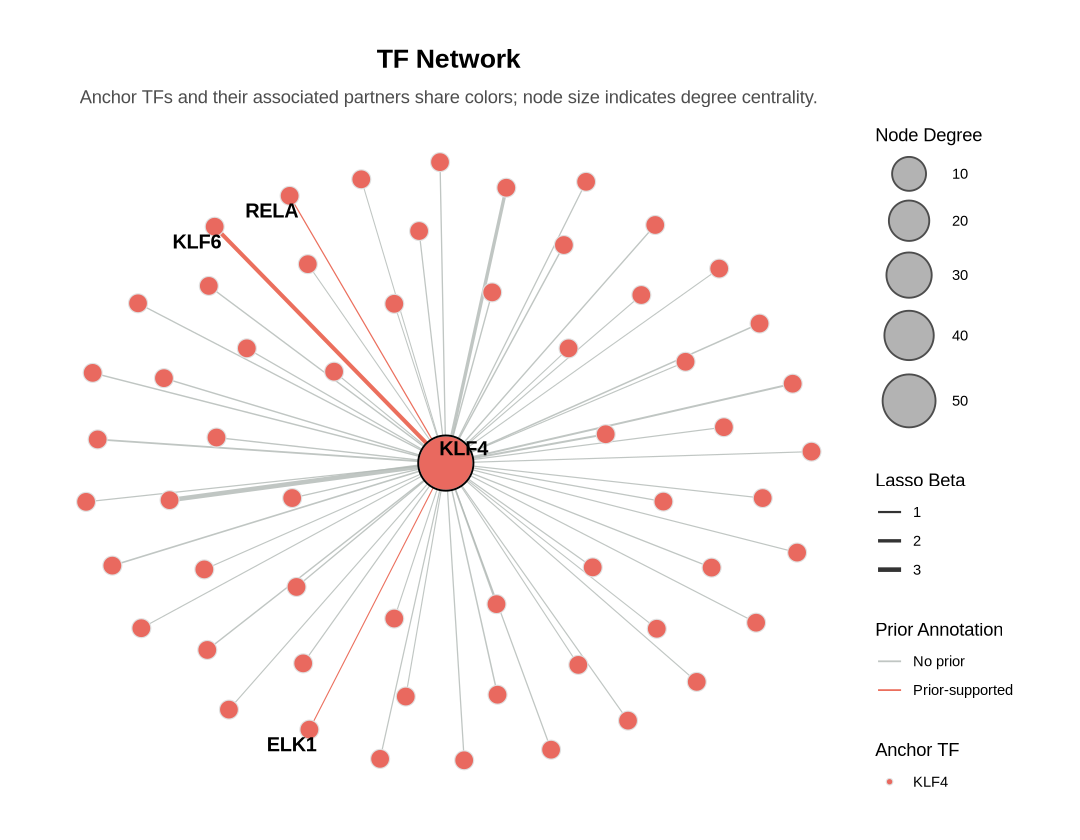

In [11]:
#TF-TF network
pair_candidates <- pair_results[['CD14+ Monocytes']]
#plot_PROACT_network(pair_candidates = pair_candidates)
anchor_tfs <- c('KLF4')
pair_candidates_sub <- pair_candidates[pair_candidates$TF1 %in% anchor_tfs|pair_candidates$TF2 %in% anchor_tfs,]
options(repr.plot.width = 9, repr.plot.height = 7)
plot_PROACT_network(
    pair_candidates = pair_candidates_sub,
    anchor_tfs = anchor_tfs
)

## Compare cooperative TF repertoires across cell types

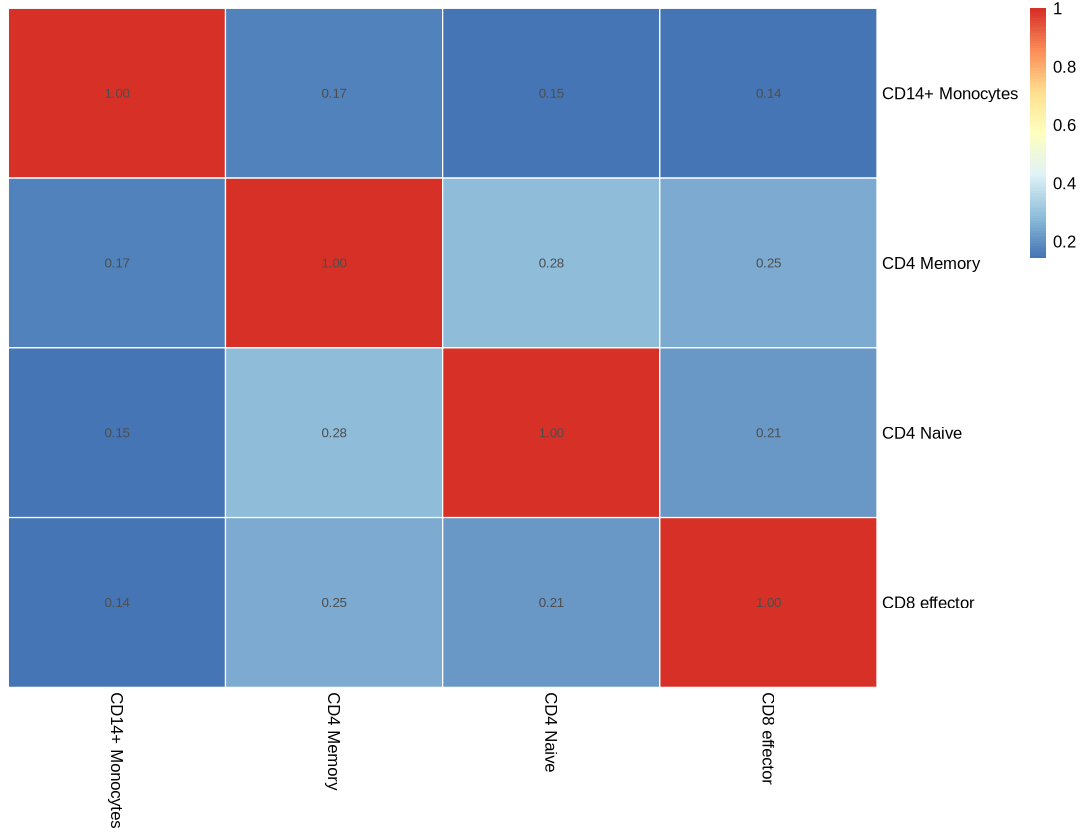

In [12]:
pair_sets <- lapply(pair_results, function(x) unique(x$pairs))

jaccard <- outer(names(pair_sets), names(pair_sets), Vectorize(function(x, y) {
    a <- pair_sets[[x]]
    b <- pair_sets[[y]]
    length(intersect(a, b)) / length(union(a, b))
}))

dimnames(jaccard) <- list(names(pair_sets), names(pair_sets))
library(pheatmap)

pheatmap(
    jaccard,
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    display_numbers = TRUE,
    number_format = "%.2f",
    border_color = "white"
)

### Session Information

In [13]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.7 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/handongmei/miniconda3/envs/R4.4/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] pheatmap_1.0.13                   PROACT_0.1.0                     
 [3] BSgenome.Hsapiens.UCSC.hg38_1.4.5 BSgenome_1.72.0                  
 [5] rtracklayer_1.64.0                BiocIO_1.14.0          